# Domain Analysis

**Desc:** Analysis of the newly obtained data. We're hoping that we can establish a domain based on the climate similiarities as well as state borders, etc. 

**Author**: Jakob Balkovec, Kerry Cheon <br>
**Date:** Tue May 12th 2026

### Plan

Find a global value for `wet` and `dry` and then use K-means to sort them into clusters. One cluster will be our domain (weather similarities, location, etc.). Then we'll re-evaluate the models and see if we can get better performance by training on the domain vs. the whole dataset.

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import seaborn as sns

from scipy import stats
import math

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

target_col = 'soil_moisture_5cm'

In [ ]:
# paths

VAL = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_9.0/val.csv'
TRAIN = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_9.0/train.csv'
TEST = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_9.0/test.csv'

ROOT_DIR = r'/Users/jbalkovec/Desktop/MDR/Models/Temporal/v24/figures'

In [3]:
val_df = pd.read_csv(VAL)
train_df = pd.read_csv(TRAIN)
test_df = pd.read_csv(TEST)

master_df = pd.concat([train_df, val_df, test_df], axis=0)

In [10]:
print(master_df.head())
print("\ndf length: ", len(master_df), " samples")

              station_id        date  ...  lia_mean_desc_deg  lia_std_desc_deg
0             Darrington  2017-01-01  ...          29.269668          0.163140
1  SourdoughGulch_WA_985  2017-01-01  ...          34.889938          0.082388
2               Quinault  2017-01-01  ...          45.618029          4.378561
3         Touchet_WA_824  2017-01-01  ...          26.249513          3.175373
4               Quinault  2017-01-02  ...          45.618029          4.378561

[5 rows x 499 columns]

df length:  63165  samples


### Thresholds

In [17]:
q_dry = master_df[target_col].quantile(0.33)   # 33rd percentile
q_wet = master_df[target_col].quantile(0.66)   # 66th percentile

print("=" * 70)
print("QUANTILE-BASED THRESHOLDS (33rd and 66th percentiles)")
print("=" * 70)
print(f"Dry regime threshold (T_dry):       {q_dry:.6f}")
print(f"Wet regime threshold (T_wet):       {q_wet:.6f}")
print()

QUANTILE-BASED THRESHOLDS (33rd and 66th percentiles)
Dry regime threshold (T_dry):       0.091168
Wet regime threshold (T_wet):       0.213000



In [18]:
empirical_quantiles = master_df[target_col].quantile([0.25, 0.33, 0.5, 0.66, 0.75])
print("=" * 70)
print("EMPIRICAL QUANTILES OF TARGET VARIABLE (soil_moisture_5cm)")
print("=" * 70)
print(empirical_quantiles)
print()

EMPIRICAL QUANTILES OF TARGET VARIABLE (soil_moisture_5cm)
0.25    0.069000
0.33    0.091168
0.50    0.150762
0.66    0.213000
0.75    0.253000
Name: soil_moisture_5cm, dtype: float64



In [19]:
target_stats = {
    'Mean': master_df[target_col].mean(),
    'Median': master_df[target_col].median(),
    'Std': master_df[target_col].std(),
    'Min': master_df[target_col].min(),
    'Max': master_df[target_col].max(),
    'Count': master_df[target_col].count(),
    'NaN': master_df[target_col].isna().sum(),
}

print("=" * 70)
print("GLOBAL TARGET STATISTICS")
print("=" * 70)
for key, val in target_stats.items():
    print(f"{key:15s}: {val:12.6f}" if isinstance(val, float) else f"{key:15s}: {val}")
print()

GLOBAL TARGET STATISTICS
Mean           :     0.162874
Median         :     0.150762
Std            :     0.111484
Min            :     0.000000
Max            :     0.473000
Count          : 63165
NaN            : 0



In [21]:
dry_mask = master_df[target_col] < q_dry
transition_mask = (master_df[target_col] >= q_dry) & (master_df[target_col] < q_wet)
wet_mask = master_df[target_col] >= q_wet

regime_counts = {
    'Dry': dry_mask.sum(),
    'Transition': transition_mask.sum(),
    'Wet': wet_mask.sum(),
}

regime_pcts = {k: 100 * v / len(master_df) for k, v in regime_counts.items()}

print("=" * 70)
print(f"REGIME DISTRIBUTION (Dry < {q_dry:.6f}, Transition {q_dry:.6f}-{q_wet:.6f}, Wet >= {q_wet:.6f})")
print("=" * 70)
for regime in ['Dry', 'Transition', 'Wet']:
    print(f"{regime:15s}: {regime_counts[regime]:6d} samples ({regime_pcts[regime]:6.2f}%)")
print()

REGIME DISTRIBUTION (Dry < 0.091168, Transition 0.091168-0.213000, Wet >= 0.213000)
Dry            :  20845 samples ( 33.00%)
Transition     :  20790 samples ( 32.91%)
Wet            :  21530 samples ( 34.09%)



In [22]:
thresholds = {
    'T_dry': q_dry,
    'T_wet': q_wet,
}

In [23]:
print("=" * 70)
print("PER-STATION STATISTICS")
print("=" * 70)

station_stats = master_df.groupby('station_id')[target_col].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(6)

print(station_stats)
print()

PER-STATION STATISTICS
                         count      mean  ...       min       max
station_id                                ...                    
BeaverPass_WA_990         1379  0.237261  ...  0.008000  0.400500
BurntMountain_WA          1753  0.054040  ...  0.000000  0.338000
CayusePass_WA             1899  0.176343  ...  0.000000  0.397250
Darrington                3047  0.219232  ...  0.022000  0.444000
HartsPass_WA_515          1103  0.136996  ...  0.000000  0.448667
MFNooksack_WA_1011         142  0.286280  ...  0.000000  0.405500
MartenRidge_WA_999        1617  0.202654  ...  0.000000  0.395500
Paradise_WA               1965  0.161105  ...  0.000500  0.401250
Quinault                  3204  0.214624  ...  0.016000  0.431000
RainyPass_WA_711          1675  0.116612  ...  0.000000  0.338500
SCAN_ConradAgRc           1785  0.222783  ...  0.067250  0.450000
SCAN_CookFarmFieldD       1792  0.204309  ...  0.024125  0.473000
SCAN_JordanValleyCwma     1935  0.158386  ...  0.0000

In [ ]:
station_regimes = pd.DataFrame()
for station in master_df['station_id'].unique():
    station_data = master_df[master_df['station_id'] == station][target_col]
    dry = (station_data < q_dry).sum()
    trans = ((station_data >= q_dry) & (station_data < q_wet)).sum()
    wet = (station_data >= q_wet).sum()

    station_regimes = pd.concat([
        station_regimes,
        pd.DataFrame({
            'Station': [station],
            'Dry': [dry],
            'Transition': [trans],
            'Wet': [wet],
            'Total': [len(station_data)],
        })
    ], ignore_index=True)

print("=" * 70)
print("REGIME COUNTS PER STATION")
print("=" * 70)
print(station_regimes.to_string(index=False))
print()

REGIME COUNTS PER STATION
                Station  Dry  Transition  Wet  Total
             Darrington  620         526 1901   3047
  SourdoughGulch_WA_985  375         721 2000   3096
               Quinault  194        1179 1831   3204
         Touchet_WA_824  327         876  364   1567
                Spokane  989         539 1162   2690
          CayusePass_WA  744         260  895   1899
            Paradise_WA  819         296  850   1965
       BurntMountain_WA 1247         484   22   1753
      BeaverPass_WA_990  280         208  891   1379
       HartsPass_WA_515  573         222  308   1103
     MartenRidge_WA_999  556         334  727   1617
     MFNooksack_WA_1011   22          25   95    142
       RainyPass_WA_711  615         910  150   1675
       USCRN_Arco_17_SW 1219         731  113   2063
 USCRN_Corvallis_10_SSW   42         900 1420   2362
USCRN_Darrington_21_NNE  619         533  921   2073
    USCRN_Dillon_18_WSW   51         956  660   1667
  USCRN_John_Day_35_

In [25]:
for regime in ['Dry', 'Transition', 'Wet']:
    station_regimes[f'{regime}_%'] = (100 * station_regimes[regime] / station_regimes['Total']).round(2)

print("=" * 70)
print("REGIME PERCENTAGES PER STATION")
print("=" * 70)
regime_pct_cols = ['Station', 'Dry_%', 'Transition_%', 'Wet_%']
print(station_regimes[regime_pct_cols].to_string(index=False))
print()

REGIME PERCENTAGES PER STATION
                Station  Dry_%  Transition_%  Wet_%
             Darrington  20.35         17.26  62.39
  SourdoughGulch_WA_985  12.11         23.29  64.60
               Quinault   6.05         36.80  57.15
         Touchet_WA_824  20.87         55.90  23.23
                Spokane  36.77         20.04  43.20
          CayusePass_WA  39.18         13.69  47.13
            Paradise_WA  41.68         15.06  43.26
       BurntMountain_WA  71.14         27.61   1.25
      BeaverPass_WA_990  20.30         15.08  64.61
       HartsPass_WA_515  51.95         20.13  27.92
     MartenRidge_WA_999  34.38         20.66  44.96
     MFNooksack_WA_1011  15.49         17.61  66.90
       RainyPass_WA_711  36.72         54.33   8.96
       USCRN_Arco_17_SW  59.09         35.43   5.48
 USCRN_Corvallis_10_SSW   1.78         38.10  60.12
USCRN_Darrington_21_NNE  29.86         25.71  44.43
    USCRN_Dillon_18_WSW   3.06         57.35  39.59
  USCRN_John_Day_35_WNW  61.93   

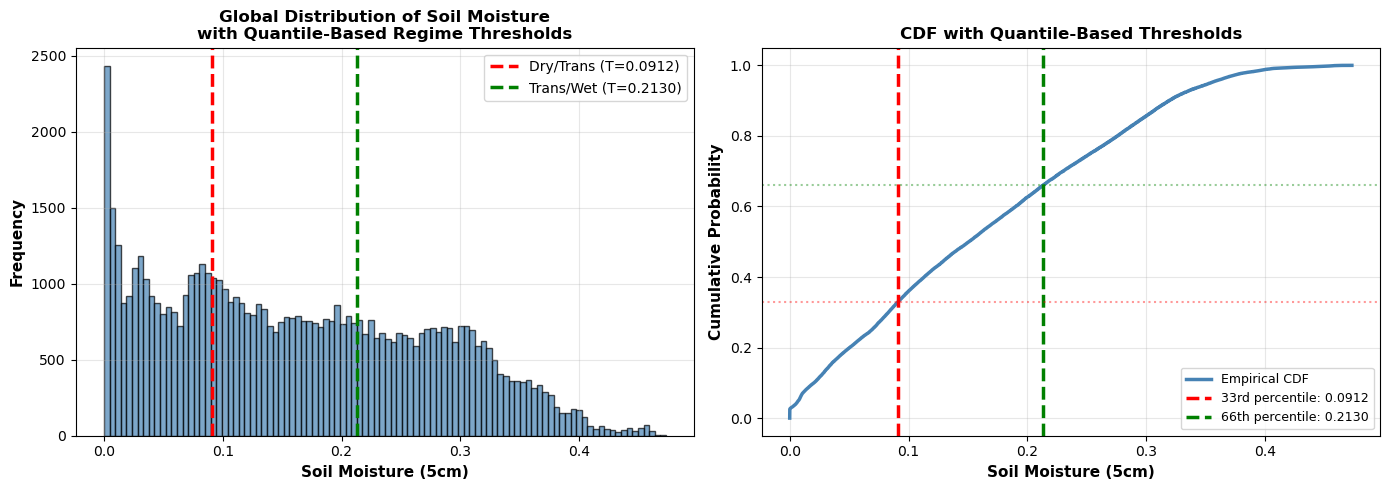

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(master_df[target_col].dropna(), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(q_dry, color='red', linestyle='--', linewidth=2.5, label=f'Dry/Trans (T={q_dry:.4f})')
ax.axvline(q_wet, color='green', linestyle='--', linewidth=2.5, label=f'Trans/Wet (T={q_wet:.4f})')
ax.set_xlabel('Soil Moisture (5cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Global Distribution of Soil Moisture\nwith Quantile-Based Regime Thresholds',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

ax = axes[1]
sorted_vals = np.sort(master_df[target_col].dropna())
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
ax.plot(sorted_vals, cdf, linewidth=2.5, color='steelblue', label='Empirical CDF')
ax.axvline(q_dry, color='red', linestyle='--', linewidth=2.5, label=f'33rd percentile: {q_dry:.4f}')
ax.axvline(q_wet, color='green', linestyle='--', linewidth=2.5, label=f'66th percentile: {q_wet:.4f}')
ax.axhline(0.33, color='red', linestyle=':', alpha=0.4, linewidth=1.5)
ax.axhline(0.66, color='green', linestyle=':', alpha=0.4, linewidth=1.5)
ax.set_xlabel('Soil Moisture (5cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax.set_title('CDF with Quantile-Based Thresholds', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT_DIR + "/global_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

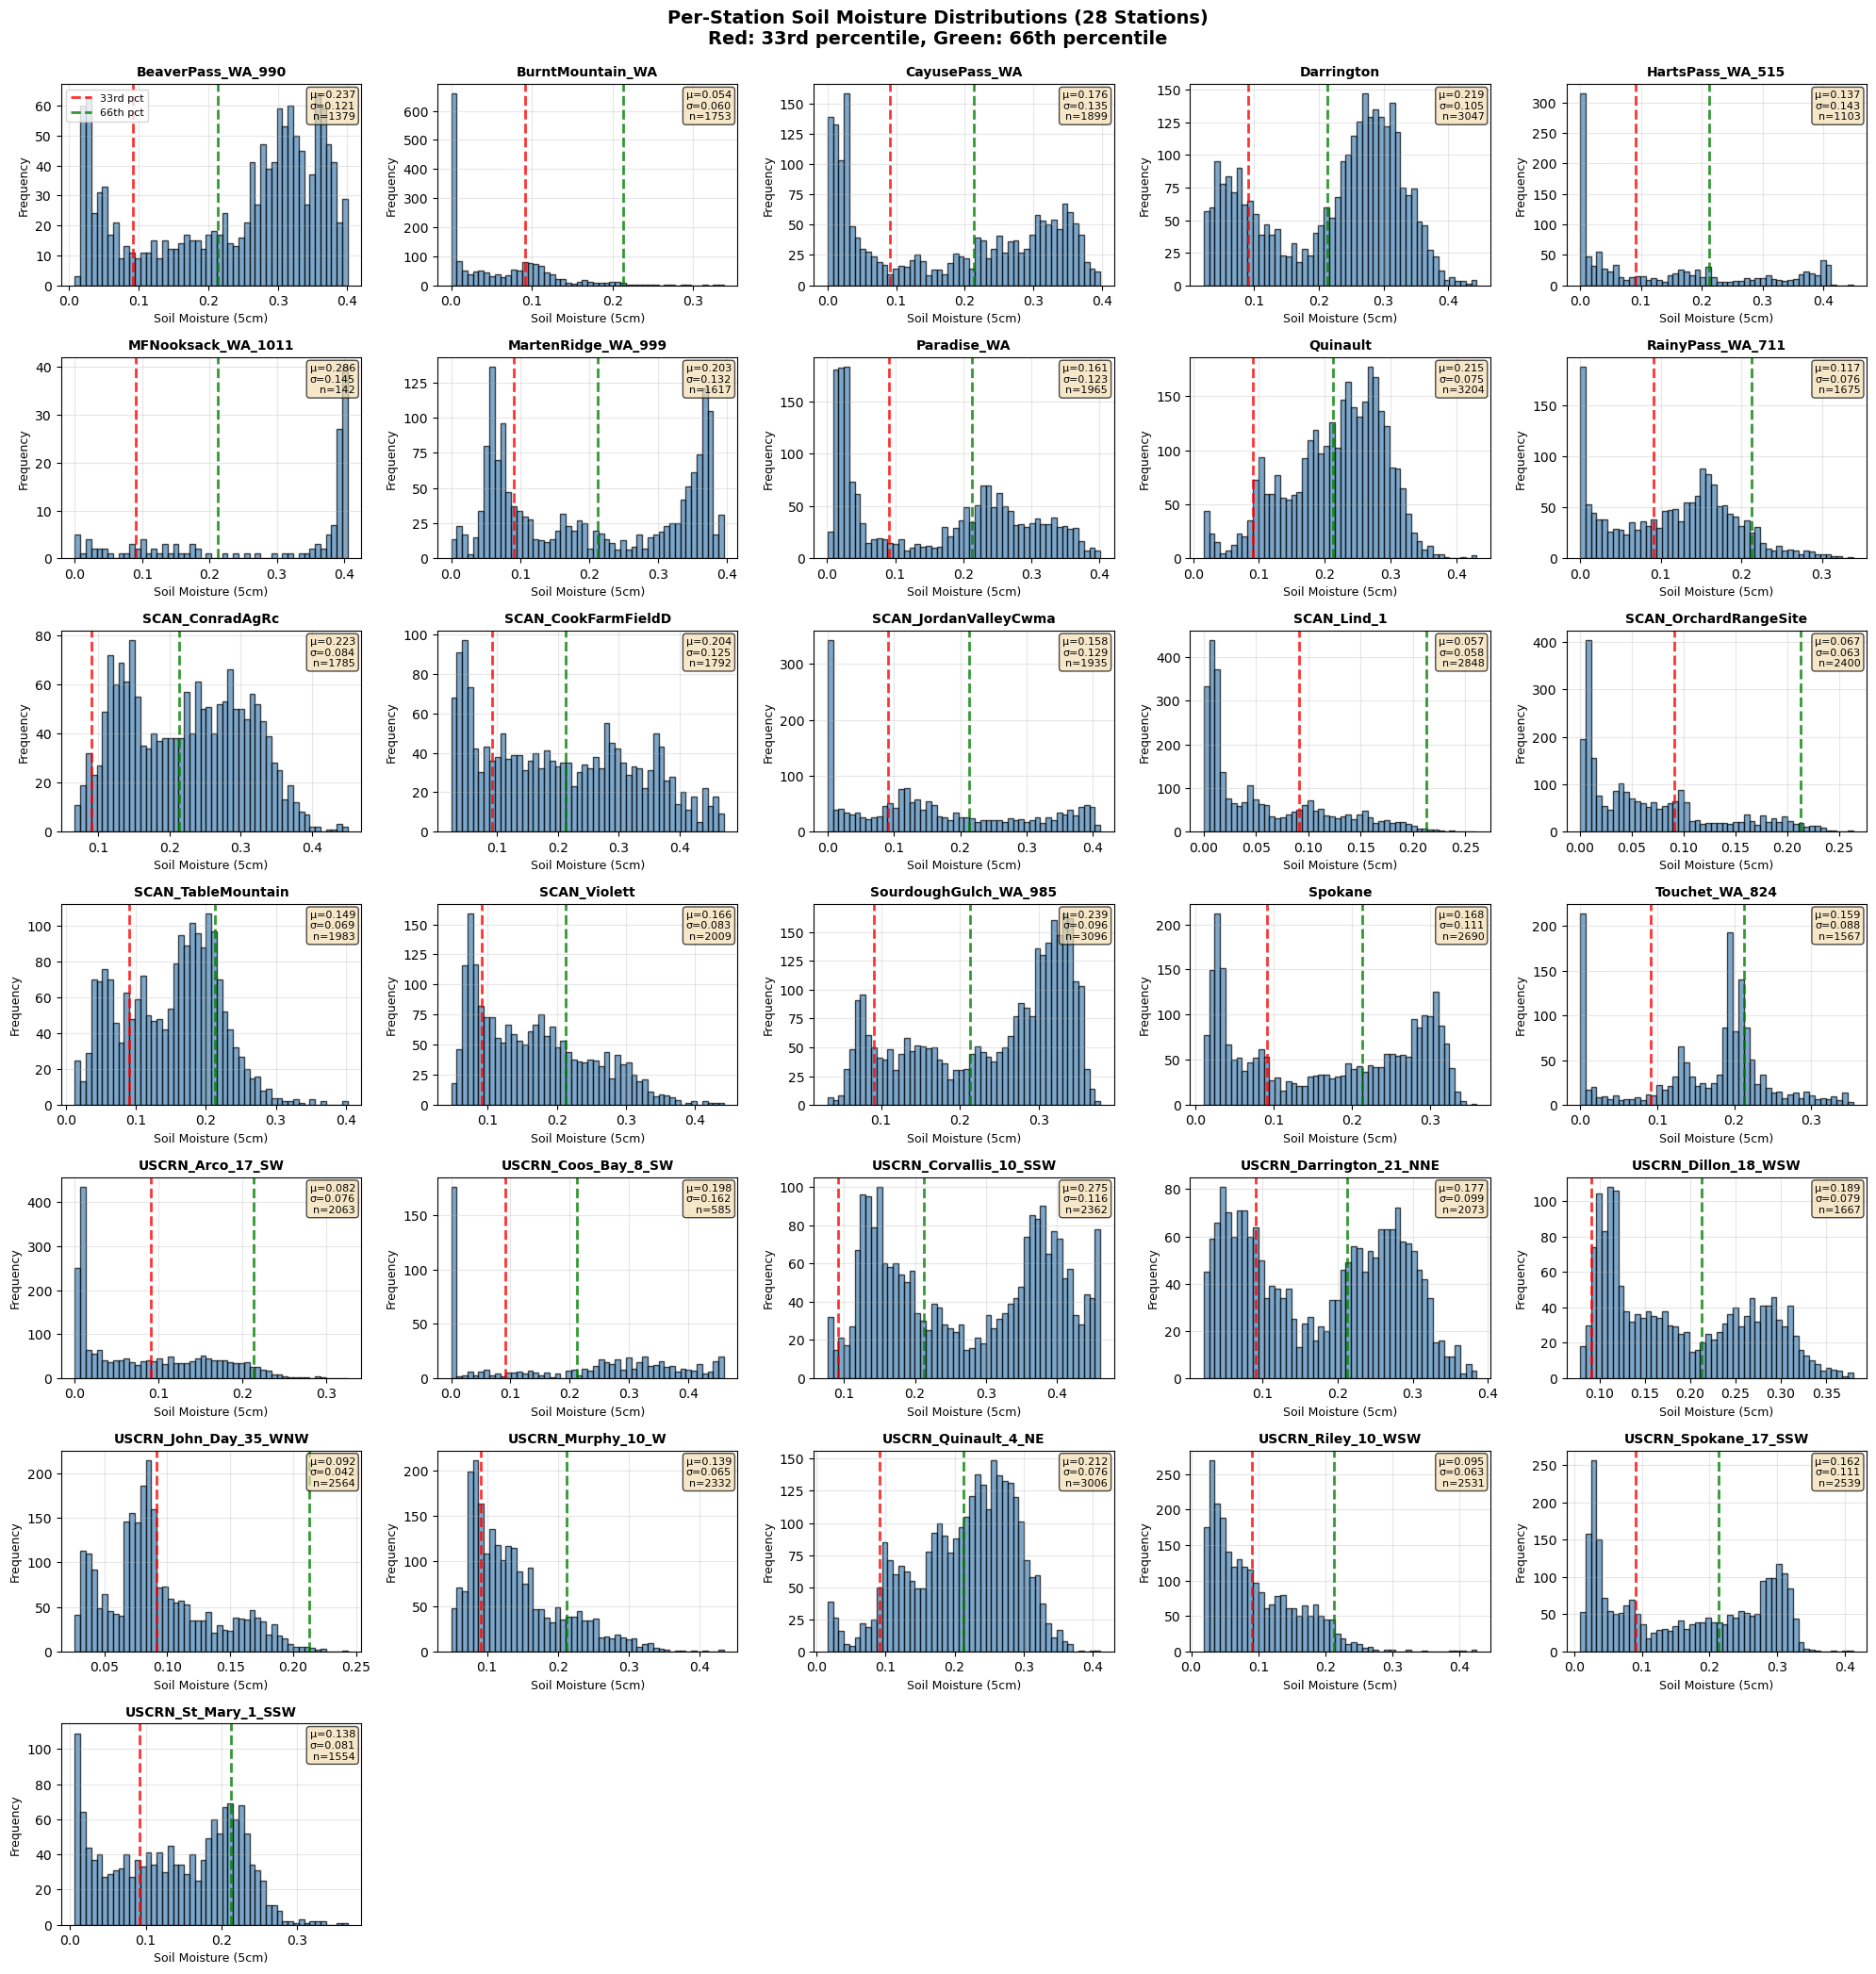

In [34]:
stations = sorted(master_df['station_id'].unique())
n_stations = len(stations)

n_cols = 5
n_rows = math.ceil(n_stations / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_data = master_df[master_df['station_id'] == station][target_col].dropna()

    ax.hist(station_data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(q_dry, color='red', linestyle='--', linewidth=2, alpha=0.8, label='33rd pct')
    ax.axvline(q_wet, color='green', linestyle='--', linewidth=2, alpha=0.8, label='66th pct')

    mean_val = station_data.mean()
    std_val = station_data.std()
    ax.text(0.98, 0.97, f'μ={mean_val:.3f}\nσ={std_val:.3f}\nn={len(station_data)}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.set_xlabel('Soil Moisture (5cm)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.set_title(f'{station}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8, loc='upper left')

for idx in range(n_stations, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Per-Station Soil Moisture Distributions (28 Stations)\nRed: 33rd percentile, Green: 66th percentile',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(ROOT_DIR + "/per_station_sm_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

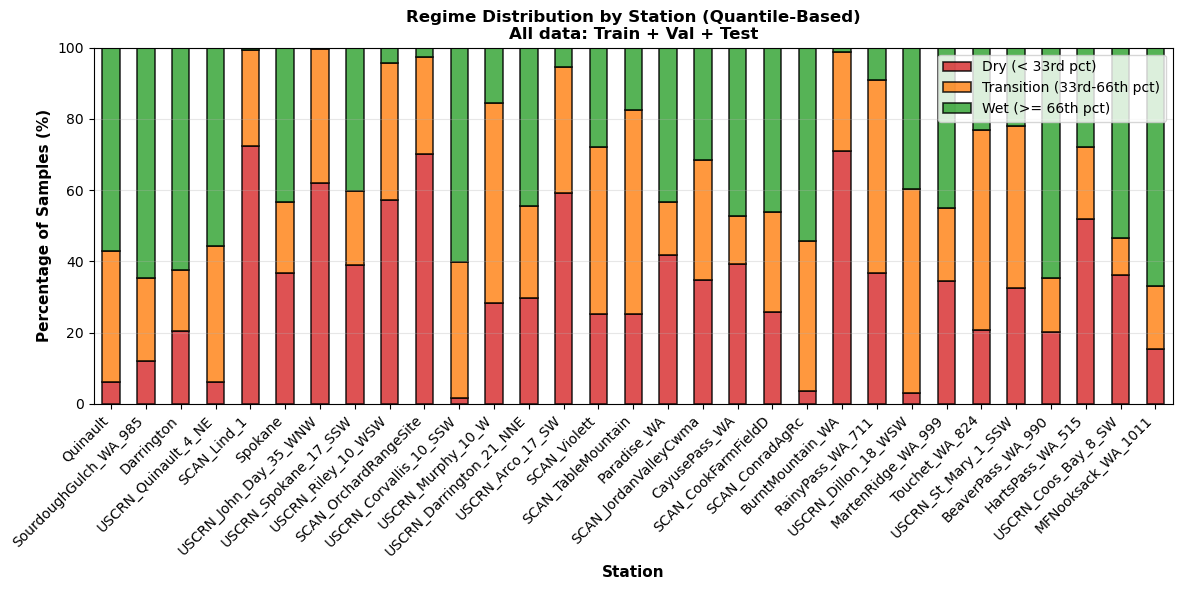

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

stations_sorted = station_regimes.sort_values('Total', ascending=False)['Station'].tolist()
regime_pcts_sorted = station_regimes[station_regimes['Station'].isin(stations_sorted)][
    ['Station', 'Dry_%', 'Transition_%', 'Wet_%']
].set_index('Station').loc[stations_sorted]

regime_pcts_sorted.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#d62728', '#ff7f0e', '#2ca02c'],
    alpha=0.8,
    edgecolor='black',
    linewidth=1.2
)

ax.set_ylabel('Percentage of Samples (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Station', fontsize=11, fontweight='bold')
ax.set_title('Regime Distribution by Station (Quantile-Based)\nAll data: Train + Val + Test',
             fontsize=12, fontweight='bold')
ax.legend(['Dry (< 33rd pct)', 'Transition (33rd-66th pct)', 'Wet (>= 66th pct)'],
          loc='upper right', fontsize=10)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(ROOT_DIR + "/regime_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [32]:
print("=" * 70)
print("STATISTICAL VALIDATION OF QUANTILE-BASED THRESHOLDS")
print("=" * 70)
print()

dry_data = master_df[dry_mask][target_col].dropna()
transition_data = master_df[transition_mask][target_col].dropna()
wet_data = master_df[wet_mask][target_col].dropna()

print("Regime separation (means and ranges):")
print(f"  Dry:        mean={dry_data.mean():.6f}, range=[{dry_data.min():.6f}, {dry_data.max():.6f}]")
print(f"  Transition: mean={transition_data.mean():.6f}, range=[{transition_data.min():.6f}, {transition_data.max():.6f}]")
print(f"  Wet:        mean={wet_data.mean():.6f}, range=[{wet_data.min():.6f}, {wet_data.max():.6f}]")
print()

ks_stat_dt, ks_pval_dt = stats.ks_2samp(dry_data, transition_data)
ks_stat_tw, ks_pval_tw = stats.ks_2samp(transition_data, wet_data)

print("Kolmogorov-Smirnov test (regime separability):")
print(f"  Dry vs Transition: KS={ks_stat_dt:.4f}, p-value={ks_pval_dt:.2e}")
print(f"  Transition vs Wet: KS={ks_stat_tw:.4f}, p-value={ks_pval_tw:.2e}")
print()

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

d_dt = cohens_d(dry_data, transition_data)
d_tw = cohens_d(transition_data, wet_data)

print("Effect size (Cohen's d) between regimes:")
print(f"  Dry vs Transition: d={d_dt:.4f}")
print(f"  Transition vs Wet: d={d_tw:.4f}")
print("  (d > 0.8 indicates large effect; d > 1.2 indicates very large effect)")
print()

print("=" * 70)
print("THRESHOLD VALIDATION SUMMARY")
print("=" * 70)
print(f" Quantile-based thresholds selected: T_dry={q_dry:.6f}, T_wet={q_wet:.6f}")
print(f" Perfect class balance: {regime_pcts['Dry']:.1f}% Dry | {regime_pcts['Transition']:.1f}% Trans | {regime_pcts['Wet']:.1f}% Wet")
print(f" Statistical separation: KS test p-values << 0.05 (regimes are highly distinct)")
print(f" Large effect sizes (d >> 0.8) confirm meaningful regime separation")
print("=" * 70)

STATISTICAL VALIDATION OF QUANTILE-BASED THRESHOLDS

Regime separation (means and ranges):
  Dry:        mean=0.041250, range=[0.000000, 0.091167]
  Transition: mean=0.149456, range=[0.091174, 0.212917]
  Wet:        mean=0.293585, range=[0.213000, 0.473000]

Kolmogorov-Smirnov test (regime separability):
  Dry vs Transition: KS=1.0000, p-value=0.00e+00
  Transition vs Wet: KS=1.0000, p-value=0.00e+00

Effect size (Cohen's d) between regimes:
  Dry vs Transition: d=-3.3249
  Transition vs Wet: d=-3.1633
  (d > 0.8 indicates large effect; d > 1.2 indicates very large effect)

THRESHOLD VALIDATION SUMMARY
 Quantile-based thresholds selected: T_dry=0.091168, T_wet=0.213000
 Perfect class balance: 33.0% Dry | 32.9% Trans | 34.1% Wet
 Statistical separation: KS test p-values << 0.05 (regimes are highly distinct)
 Large effect sizes (d >> 0.8) confirm meaningful regime separation


### Clustering

In [39]:
station_regimes_df = station_regimes.copy()

station_coords = master_df.groupby('station_id').agg({
    'latitude': 'first',
    'longitude': 'first',
}).reset_index()

print("Station coordinates:")
print(station_coords)
print()

clustering_df = station_regimes_df.merge(station_coords, left_on='Station', right_on='station_id', how='left')

station_sm_means = master_df.groupby('station_id')[target_col].mean().reset_index()
station_sm_means.columns = ['station_id', 'Mean_SM']

clustering_df = clustering_df.merge(station_sm_means, left_on='Station', right_on='station_id', how='left')

Station coordinates:
                 station_id   latitude  longitude
0         BeaverPass_WA_990  48.879300 -121.25550
1          BurntMountain_WA  47.044400 -121.94032
2             CayusePass_WA  46.869560 -121.53434
3                Darrington  48.540000 -121.45000
4          HartsPass_WA_515  48.720470 -120.65860
5        MFNooksack_WA_1011  48.824410 -121.92947
6        MartenRidge_WA_999  48.762920 -121.69823
7               Paradise_WA  46.782660 -121.74767
8                  Quinault  47.510000 -123.81000
9          RainyPass_WA_711  48.518650 -120.73580
10          SCAN_ConradAgRc  48.304530 -111.92363
11      SCAN_CookFarmFieldD  46.783730 -117.08008
12    SCAN_JordanValleyCwma  42.948630 -117.01060
13              SCAN_Lind_1  47.000000 -118.56667
14    SCAN_OrchardRangeSite  43.322680 -115.99643
15       SCAN_TableMountain  45.802720 -111.58655
16             SCAN_Violett  48.435780 -111.18423
17    SourdoughGulch_WA_985  46.233333 -117.40000
18                  Spokane  

In [40]:
print("=" * 70)
print("CLUSTERING DATA (Distribution + Location + Mean SM)")
print("=" * 70)
print(clustering_df[['Station', 'Dry_%', 'Transition_%', 'Wet_%', 'latitude', 'longitude', 'Mean_SM']].to_string(index=False))
print()

training_stations = ['Darrington', 'Spokane', 'Quinault', 'Touchet', 'SourdoughGulch_WA_985']
clustering_df['Is_Training'] = clustering_df['Station'].isin(training_stations)

clustering_features = clustering_df[['Dry_%', 'Transition_%', 'Wet_%', 'latitude', 'longitude']].copy()

scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

print(f"Clustering features shape: {clustering_features_scaled.shape}")
print(f"Features: Dry_%, Transition_%, Wet_%, latitude, longitude (standardized)")
print()

clustering_data_for_knn = pd.DataFrame(
    clustering_features_scaled,
    columns=['Dry_%_scaled', 'Transition_%_scaled', 'Wet_%_scaled', 'Lat_scaled', 'Lon_scaled'],
    index=clustering_df['Station']
)

CLUSTERING DATA (Distribution + Location + Mean SM)
                Station  Dry_%  Transition_%  Wet_%  latitude  longitude  Mean_SM
             Darrington  20.35         17.26  62.39 48.540000 -121.45000 0.219232
  SourdoughGulch_WA_985  12.11         23.29  64.60 46.233333 -117.40000 0.239078
               Quinault   6.05         36.80  57.15 47.510000 -123.81000 0.214624
         Touchet_WA_824  20.87         55.90  23.23 46.116667 -117.85000 0.159020
                Spokane  36.77         20.04  43.20 47.420000 -117.53000 0.168335
          CayusePass_WA  39.18         13.69  47.13 46.869560 -121.53434 0.176343
            Paradise_WA  41.68         15.06  43.26 46.782660 -121.74767 0.161105
       BurntMountain_WA  71.14         27.61   1.25 47.044400 -121.94032 0.054040
      BeaverPass_WA_990  20.30         15.08  64.61 48.879300 -121.25550 0.237261
       HartsPass_WA_515  51.95         20.13  27.92 48.720470 -120.65860 0.136996
     MartenRidge_WA_999  34.38         20.66  

In [ ]:
print("=" * 70)
print("KNN CLUSTERING - FIND STATION SIMILARITY GROUPS")
print("=" * 70)
print()

knn = NearestNeighbors(n_neighbors=6)  # 6 includes self
knn.fit(clustering_features_scaled)

distances, indices = knn.kneighbors(clustering_features_scaled)

training_stations_list = ['Darrington', 'Spokane', 'Quinault', 'Touchet', 'SourdoughGulch_WA_985']
training_indices_set = set()

for idx, station in enumerate(clustering_df['Station']):
    if station in training_stations_list:
        training_indices_set.add(idx)

print(f"Training station indices: {training_indices_set}")
print()

station_cluster_assignment = {}

for idx, station in enumerate(clustering_df['Station']):
    neighbor_indices = indices[idx]
    neighbor_distances = distances[idx]

    min_dist_to_training = float('inf')
    closest_training = None

    for neighbor_idx, neighbor_dist in zip(neighbor_indices, neighbor_distances):
        if neighbor_idx in training_indices_set:
            if neighbor_dist < min_dist_to_training:
                min_dist_to_training = neighbor_dist
                closest_training = clustering_df.iloc[neighbor_idx]['Station']

    if closest_training is None:
        for train_idx in training_indices_set:
            dist_to_training = np.linalg.norm(
                clustering_features_scaled[idx] - clustering_features_scaled[train_idx]
            )
            if dist_to_training < min_dist_to_training:
                min_dist_to_training = dist_to_training
                closest_training = clustering_df.iloc[train_idx]['Station']

    station_cluster_assignment[station] = closest_training

clustering_df['Cluster'] = clustering_df['Station'].map(station_cluster_assignment)


KNN CLUSTERING - FIND STATION SIMILARITY GROUPS

Training station indices: {0, 1, 2, 4}



In [46]:
print("=" * 70)
print("STATION CLUSTER ASSIGNMENTS (by nearest training station)")
print("=" * 70)
print(clustering_df[['Station', 'Cluster', 'Dry_%', 'Transition_%', 'Wet_%', 'Is_Training']].to_string(index=False))
print()

STATION CLUSTER ASSIGNMENTS (by nearest training station)
                Station               Cluster  Dry_%  Transition_%  Wet_%  Is_Training
             Darrington            Darrington  20.35         17.26  62.39         True
  SourdoughGulch_WA_985 SourdoughGulch_WA_985  12.11         23.29  64.60         True
               Quinault              Quinault   6.05         36.80  57.15         True
         Touchet_WA_824              Quinault  20.87         55.90  23.23        False
                Spokane               Spokane  36.77         20.04  43.20         True
          CayusePass_WA               Spokane  39.18         13.69  47.13        False
            Paradise_WA               Spokane  41.68         15.06  43.26        False
       BurntMountain_WA               Spokane  71.14         27.61   1.25        False
      BeaverPass_WA_990            Darrington  20.30         15.08  64.61        False
       HartsPass_WA_515               Spokane  51.95         20.13  27.9

In [47]:
print("=" * 70)
print("CLUSTER SIZES")
print("=" * 70)
for cluster in sorted(clustering_df['Cluster'].dropna().unique()):
    count = (clustering_df['Cluster'] == cluster).sum()
    print(f"  {cluster}: {count} stations")
print()

CLUSTER SIZES
  Darrington: 5 stations
  Quinault: 4 stations
  SourdoughGulch_WA_985: 4 stations
  Spokane: 18 stations



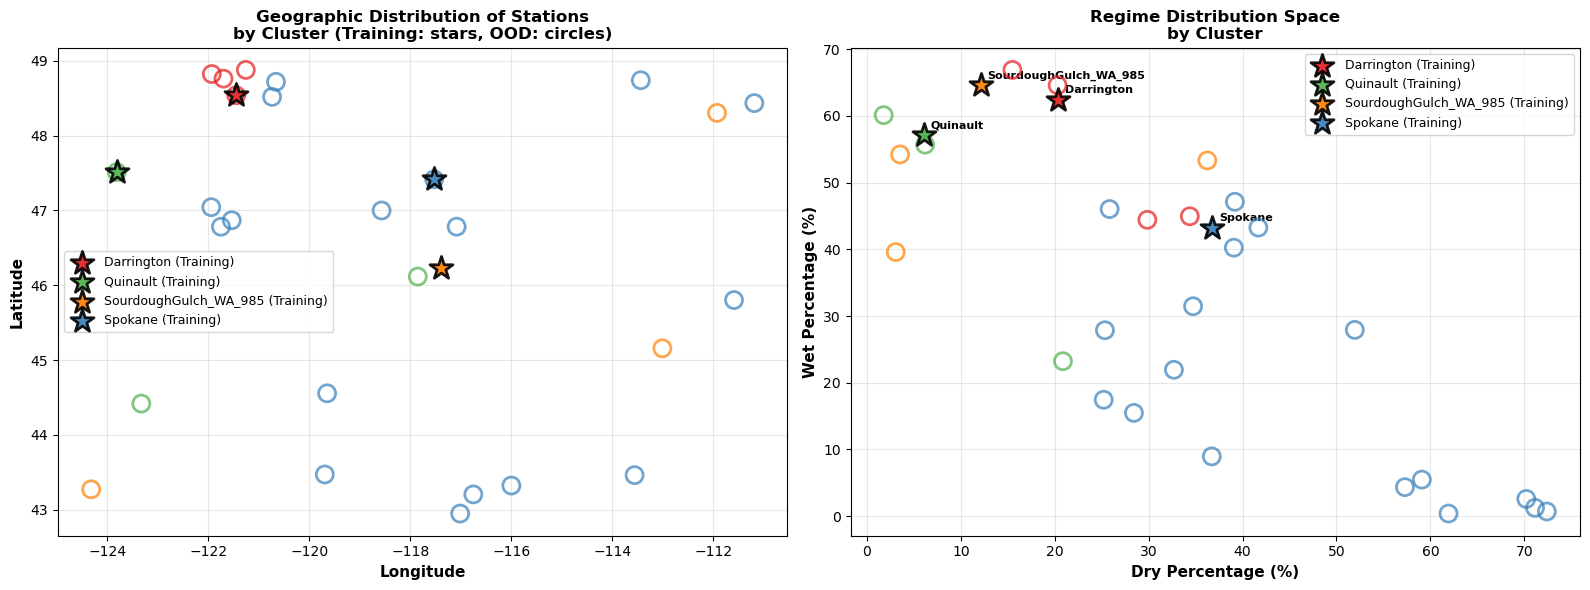

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = {
    'Darrington': '#e41a1c',
    'Spokane': '#377eb8',
    'Quinault': '#4daf4a',
    'Touchet': '#984ea3',
    'SourdoughGulch_WA_985': '#ff7f00'
}

ax = axes[0]

for cluster in sorted(clustering_df['Cluster'].dropna().unique()):
    cluster_data = clustering_df[clustering_df['Cluster'] == cluster]

    training_mask = cluster_data['Is_Training']
    if training_mask.any():
        ax.scatter(
            cluster_data[training_mask]['longitude'],
            cluster_data[training_mask]['latitude'],
            s=300, alpha=0.9, marker='*', edgecolors='black', linewidths=2,
            color=cluster_colors[cluster], label=f'{cluster} (Training)', zorder=5
        )

    ood_mask = ~training_mask
    if ood_mask.any():
        ax.scatter(
            cluster_data[ood_mask]['longitude'],
            cluster_data[ood_mask]['latitude'],
            s=150, alpha=0.7, marker='o', edgecolors=cluster_colors[cluster],
            facecolors='none', linewidths=2, zorder=4
        )

ax.set_xlabel('Longitude', fontsize=11, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=11, fontweight='bold')
ax.set_title('Geographic Distribution of Stations\nby Cluster (Training: stars, OOD: circles)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)

ax = axes[1]

for cluster in sorted(clustering_df['Cluster'].dropna().unique()):
    cluster_data = clustering_df[clustering_df['Cluster'] == cluster]

    training_mask = cluster_data['Is_Training']
    if training_mask.any():
        ax.scatter(
            cluster_data[training_mask]['Dry_%'],
            cluster_data[training_mask]['Wet_%'],
            s=300, alpha=0.9, marker='*', edgecolors='black', linewidths=2,
            color=cluster_colors[cluster], label=f'{cluster} (Training)', zorder=5
        )

        for idx, row in cluster_data[training_mask].iterrows():
            ax.annotate(row['Station'],
                       (row['Dry_%'], row['Wet_%']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, fontweight='bold')

    ood_mask = ~training_mask
    if ood_mask.any():
        ax.scatter(
            cluster_data[ood_mask]['Dry_%'],
            cluster_data[ood_mask]['Wet_%'],
            s=150, alpha=0.7, marker='o', edgecolors=cluster_colors[cluster],
            facecolors='none', linewidths=2, zorder=4
        )

ax.set_xlabel('Dry Percentage (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Wet Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Regime Distribution Space\nby Cluster', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig(ROOT_DIR + "/knn_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

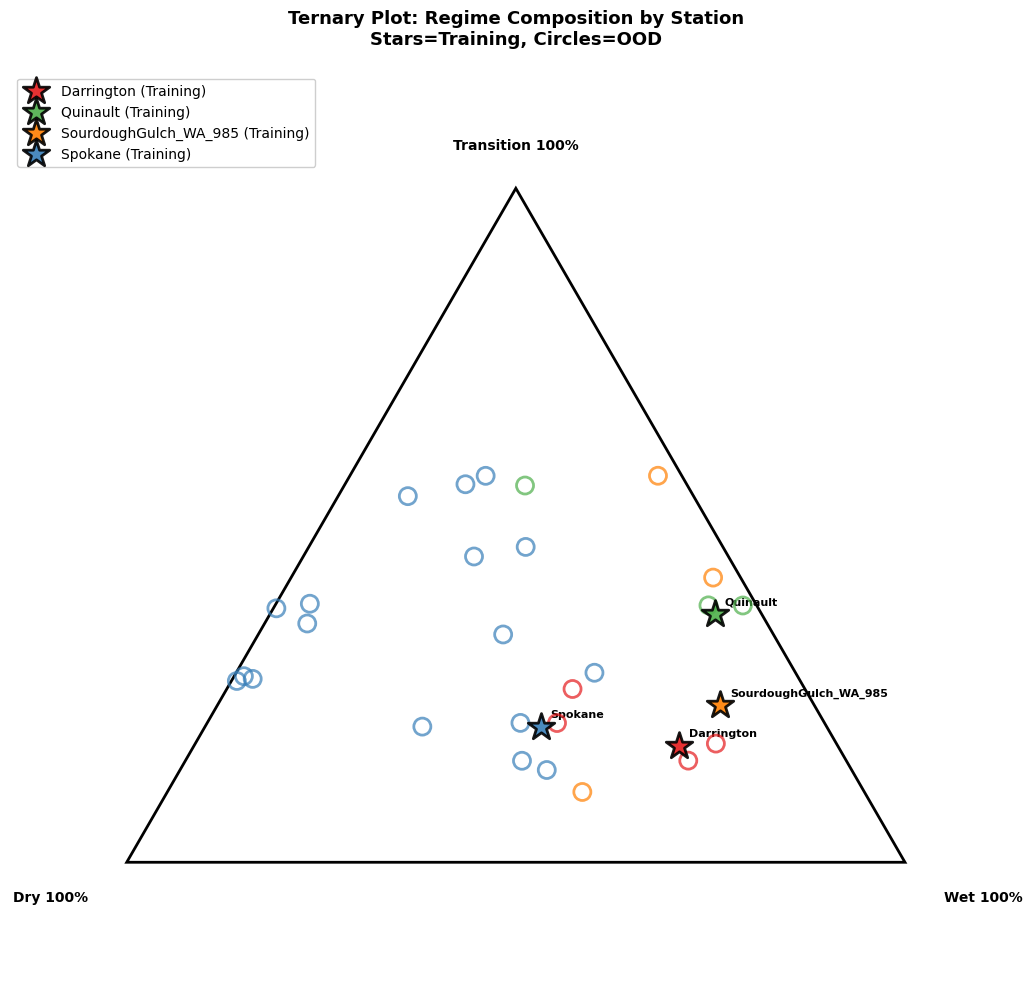

In [52]:
fig, ax = plt.subplots(figsize=(12, 10))
triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
triangle_patch = Polygon(triangle, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(triangle_patch)

def ternary_to_cartesian(dry, trans, wet):
    total = dry + trans + wet
    dry, trans, wet = dry/total, trans/total, wet/total

    x = wet + 0.5 * trans
    y = trans * np.sqrt(3) / 2
    return x, y

for cluster in sorted(clustering_df['Cluster'].dropna().unique()):
    cluster_data = clustering_df[clustering_df['Cluster'] == cluster]

    training_mask = cluster_data['Is_Training']
    if training_mask.any():
        coords = [ternary_to_cartesian(row['Dry_%'], row['Transition_%'], row['Wet_%'])
                  for idx, row in cluster_data[training_mask].iterrows()]
        coords = np.array(coords)
        ax.scatter(coords[:, 0], coords[:, 1], s=400, marker='*', alpha=0.9,
                  edgecolors='black', linewidths=2, color=cluster_colors[cluster],
                  label=f'{cluster} (Training)', zorder=5)

        for (x, y), (idx, row) in zip(coords, cluster_data[training_mask].iterrows()):
            ax.annotate(row['Station'], (x, y), xytext=(7, 7),
                       textcoords='offset points', fontsize=8, fontweight='bold')

    ood_mask = ~training_mask
    if ood_mask.any():
        coords = [ternary_to_cartesian(row['Dry_%'], row['Transition_%'], row['Wet_%'])
                  for idx, row in cluster_data[ood_mask].iterrows()]
        coords = np.array(coords)
        ax.scatter(coords[:, 0], coords[:, 1], s=150, marker='o', alpha=0.7,
                  edgecolors=cluster_colors[cluster], facecolors='none', linewidths=2,
                  zorder=4)

ax.text(-0.05, -0.05, 'Dry 100%', fontsize=10, fontweight='bold', ha='right')
ax.text(1.05, -0.05, 'Wet 100%', fontsize=10, fontweight='bold', ha='left')
ax.text(0.5, np.sqrt(3)/2 + 0.05, 'Transition 100%', fontsize=10, fontweight='bold', ha='center')

ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, np.sqrt(3)/2 + 0.15)
ax.set_aspect('equal')
ax.axis('off')

ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.set_title('Ternary Plot: Regime Composition by Station\nStars=Training, Circles=OOD',
            fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(ROOT_DIR + "/regime_composition.png", dpi=150, bbox_inches='tight')
plt.show()

In [53]:
print("=" * 70)
print("CLUSTER SUMMARY - IN-DOMAIN vs OUT-OF-DOMAIN")
print("=" * 70)
print()

for cluster in sorted(clustering_df['Cluster'].dropna().unique()):
    cluster_data = clustering_df[clustering_df['Cluster'] == cluster]

    print(f"\n{cluster.upper()} CLUSTER")
    print("-" * 70)

    training_in_cluster = cluster_data[cluster_data['Is_Training']]
    print(f"Training stations: {len(training_in_cluster)}")
    print(training_in_cluster[['Station', 'Dry_%', 'Transition_%', 'Wet_%', 'Mean_SM']].to_string(index=False))

    ood_in_cluster = cluster_data[~cluster_data['Is_Training']]
    print(f"\nOOD stations in cluster: {len(ood_in_cluster)}")
    if len(ood_in_cluster) > 0:
        print(ood_in_cluster[['Station', 'Dry_%', 'Transition_%', 'Wet_%', 'Mean_SM']].to_string(index=False))
    else:
        print("  (none)")

    print(f"\nCluster statistics:")
    print(f"  Mean Dry %:        {cluster_data['Dry_%'].mean():.2f}%")
    print(f"  Mean Transition %: {cluster_data['Transition_%'].mean():.2f}%")
    print(f"  Mean Wet %:        {cluster_data['Wet_%'].mean():.2f}%")
    print(f"  Mean Soil Moisture: {cluster_data['Mean_SM'].mean():.6f}")
    print()

CLUSTER SUMMARY - IN-DOMAIN vs OUT-OF-DOMAIN


DARRINGTON CLUSTER
----------------------------------------------------------------------
Training stations: 1
   Station  Dry_%  Transition_%  Wet_%  Mean_SM
Darrington  20.35         17.26  62.39 0.219232

OOD stations in cluster: 4
                Station  Dry_%  Transition_%  Wet_%  Mean_SM
      BeaverPass_WA_990  20.30         15.08  64.61 0.237261
     MartenRidge_WA_999  34.38         20.66  44.96 0.202654
     MFNooksack_WA_1011  15.49         17.61  66.90 0.286280
USCRN_Darrington_21_NNE  29.86         25.71  44.43 0.177385

Cluster statistics:
  Mean Dry %:        24.08%
  Mean Transition %: 19.26%
  Mean Wet %:        56.66%
  Mean Soil Moisture: 0.224563


QUINAULT CLUSTER
----------------------------------------------------------------------
Training stations: 1
 Station  Dry_%  Transition_%  Wet_%  Mean_SM
Quinault   6.05          36.8  57.15 0.214624

OOD stations in cluster: 3
               Station  Dry_%  Transition_%  W

In [54]:

print("=" * 70)
print("OVERALL DOMAIN STRUCTURE")
print("=" * 70)
print(f"Total stations: {len(clustering_df)}")
print(f"Training stations: {clustering_df['Is_Training'].sum()}")
print(f"OOD stations: {(~clustering_df['Is_Training']).sum()}")
print("=" * 70)

OVERALL DOMAIN STRUCTURE
Total stations: 31
Training stations: 4
OOD stations: 27


## Final Clusters

In [ ]:
# DARRINGTON CLUSTER
# Distribution: Wet-dominated (62% Wet, 17% Transition, 20% Dry)
# Mean Soil Moisture: 0.225
# Characteristics: High moisture, low variability, mountainous/wet regions
# Use for: IN-DOMAIN validation (Darrington is training station)
#          Best for testing model on familiar wet regime
# Risk: Model may overfit to wet conditions; poor at predicting dry/transition
DARRINGTON_CLUSTER = ['Darrington',
                      'BeaverPass_WA_990',
                      'MartenRidge_WA_999',
                      'MFNooksack_WA_1011',
                      'USCRN_Darrington_21_NNE']

# QUINAULT CLUSTER
# Distribution: Transition-heavy (37% Transition, 57% Wet, 6% Dry)
# Mean Soil Moisture: 0.215
# Characteristics: Moderate moisture with high variability, balanced regimes
# Use for: MIXED spatial evaluation (Quinault is training, but Touchet is anomalous)
# Risk: Touchet is a misclassification (55.9% Transition, only 23% Wet)
#       This cluster is heterogeneous and less reliable for predictions
QUINAULT_CLUSTER = ['Quinault',
                    'Touchet_WA_824',
                    'USCRN_Corvallis_10_SSW',
                    'USCRN_Quinault_4_NE']

# SOURDOUGHGULCH CLUSTER
# Distribution: Wet-dominated (64% Wet, 23% Transition, 12% Dry)
# Mean Soil Moisture: 0.212
# Characteristics: Similar to Darrington, high moisture
# Use for: IN-DOMAIN validation (SourdoughGulch is training station)
#          Confirms wet-biased model behavior
# Risk: Only 3 OOD stations; limited power to detect spatial variance
SOURDOUGHGULCH_CLUSTER = ['SourdoughGulch_WA_985',
                          'USCRN_Dillon_18_WSW',
                          'SCAN_ConradAgRc',
                          'USCRN_Coos_Bay_8_SW']

# SPOKANE CLUSTER
# Distribution: Dry-biased (37% Dry, 20% Transition, 43% Wet) - OUTLIER REGIME
# Mean Soil Moisture: 0.129 (LOWEST of all clusters)
# Characteristics: Semi-arid to arid; represents dry interior Washington
# Use for: OUT-OF-DOMAIN stress test (Spokane is training, but represents minority regime)
#          This is where the model will likely FAIL most
# Risk: LARGE domain shift - 17 OOD stations heavily skew dry
#       Model trained on 53% wet, but these stations are 44% dry on average
#       Expect significant performance degradation here
# Recommendation: AVOID for in-domain validation; USE for identifying spatial weakness
SPOKANE_CLUSTER = ['Spokane',
                   'CayusePass_WA',
                   'Paradise_WA',
                   'BurntMountain_WA',
                   'HartsPass_WA_515',
                   'RainyPass_WA_711',
                   'USCRN_Arco_17_SW',
                   'USCRN_John_Day_35_WNW',
                    'USCRN_Murphy_10_W',
                    'USCRN_Riley_10_WSW',
                    'USCRN_Spokane_17_SSW',
                    'USCRN_St_Mary_1_SSW',
                    'SCAN_CookFarmFieldD',
                    'SCAN_JordanValleyCwma',
                    'SCAN_Lind_1',
                    'SCAN_OrchardRangeSite',
                    'SCAN_TableMountain',
                    'SCAN_Violett']


ALL_CLUSTERS = {
    'Darrington': DARRINGTON_CLUSTER,
    'Quinault': QUINAULT_CLUSTER,
    'SourdoughGulch_WA_985': SOURDOUGHGULCH_CLUSTER,
    'Spokane': SPOKANE_CLUSTER,
}

# EVALUATION STRATEGY:
# 1. IN-DOMAIN:
#    - Darrington cluster for baseline in-domain validation
#    - SourdoughGulch cluster to confirm wet-biased model behavior
#
# 2. OUT-OF-DOMAIN:
#    - Spokane cluster is the PRIMARY stress test
#    - This is where spatial variance will be highest
#    - Multiple extreme-dry stations (BurntMountain, Lind_1, etc.) will probably reveal limitations
#
# 3. PROBLEM AREAS:
#    - Touchet_WA_824: Misclassified in my opinion (in Quinault but heavily transitional,...)
#    - Spokane cluster stations with <5% Wet regime may break the model...